[Gold, Silver & Precious Metals Futures Daily Data](https://www.kaggle.com/datasets/guillemservera/precious-metals-data)

# STAT5291 Project Code

In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from pathlib import Path
import utility_func

FIGURE_DIR = Path("figure")
DATA_PROCESSED_DIR = 'data/data_processed/'
DATA_RAW_DIR = 'data/data_raw/'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:

df = pd.read_csv('data/data_raw/all_commodities_data.csv')
df.columns = ['Ticker', 'Commodity', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']
df['Commodity'].unique()

# 从yahoo finance上获取数据
ticker_list = ['GC=F', 'SI=F', 'PL=F', 'HG=F', 'PA=F']
comm_list = ['Gold', 'Silver', 'Platinum', 'Copper', 'Palladium']

end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)
def yfinance_fetch_price(ticker_name, comm_name, start=start_date):
    ticker = yf.Ticker(ticker_name)
    df1 = ticker.history(start=start, end=pd.Timestamp.now())
    df1.drop(columns=['Dividends', 'Stock Splits'], inplace=True)
    df1.reset_index(inplace=True)
    df1['Date'] = df1['Date'].map(lambda x: x.strftime('%Y/%m/%d'))
    df1.drop_duplicates(subset=['Date'], keep='first')
    df1['Ticker'] = ticker_name
    df1['Commodity'] = comm_name
    return df1
bdf = pd.DataFrame()


for ticker, commodity in zip(ticker_list, comm_list):
    temp_df = yfinance_fetch_price(ticker, commodity)
    bdf = pd.concat([bdf,temp_df])
bdf.to_csv('all_commodities_data1.csv')
# df = pd.concat([df, bdf])
# df.reset_index(inplace=True)
# # 保存到csv文件
# df.to_csv('all_commodities_data1.csv')


# S&P500 and VIX Data Download

In [3]:
# Download 20 years of S&P 500 data
ticker = "^GSPC"  # S&P 500 symbol
end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)

# Download the data
sp500_data = yf.download(ticker, start=start_date, end=end_date)
sp500_data.reset_index(inplace=True)
sp500_data.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volumn']
sp500_data = sp500_data[['Date', 'Close']]
sp500_data.to_csv('data/data_raw/sp500.csv',index=False)

# --- VIX ---
# VIX指数的代码是 ^VIX
ticker = "^VIX"
end_date = datetime.now()
start_date = end_date - timedelta(days=20*365)

# 下载VIX数据
vix_data = yf.download(ticker, start=start_date, end=end_date)
vix_data = vix_data.reset_index()
vix_data = vix_data[['Date', 'Close']]
vix_data.columns = ['Date', 'Close']

# 保存为CSV文件
vix_data.to_csv('vix.csv',index=False)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Wrangling and Merge Data to data.csv

In [4]:
all_commodity = pd.read_csv('data/data_processed/all_commodities_data1.csv')

pt = pd.pivot_table(all_commodity, 'Close', index='Date', columns='Commodity', aggfunc='sum')
pt.index = pd.to_datetime(pt.index, dayfirst=True)
pt = pt.sort_index()

sp500 = pd.read_csv('sp500.csv')
vix = pd.read_csv('vix.csv')

sp500 = sp500.set_index(sp500['Date'])
vix = vix.set_index(vix['Date'])
sp500.index = pd.to_datetime(sp500.index)
vix.index = pd.to_datetime(vix.index)

pt['sp500'] = sp500['Close']
pt['vix'] = vix['Close']

panic_days = pd.read_csv('data/panic_days.csv')
panic_day_list = pd.to_datetime(panic_days['Date'],dayfirst=True).tolist()
pt['is_panic_day'] = pt.index.isin(panic_day_list).astype(int)

pt.to_csv('data.csv')

C:\Users\jimmy\AppData\Local\Temp\ipykernel_82420\2190434239.py:4: UserWarning: Parsing dates in %Y/%m/%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  pt.index = pd.to_datetime(pt.index, dayfirst=True)


FileNotFoundError: [Errno 2] No such file or directory: 'sp500.csv'

# EDA
## Generate Time Series Plot

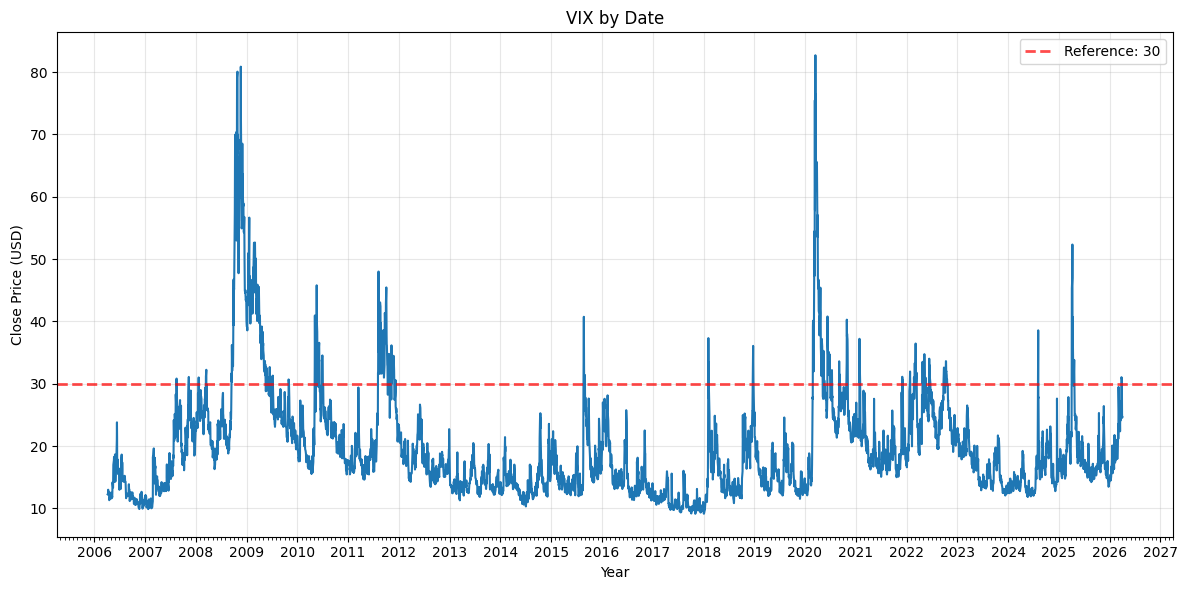

In [5]:
from utility_func import plot_time_series
plot_time_series(vix_data, hline=30, save_path=FIGURE_DIR / "vix_hline_30.png", title="VIX by Date")

## Define Log Return Data

In [ ]:
data = pd.read_csv('data/data_processed/data.csv')
data = data.set_index('Date')
data.columns
col = ['Copper', 'Gold', 'Palladium', 'Platinum', 'Silver', 'sp500']
log_returns = np.log(data[col]).diff()

Ret_data = pd.concat([log_returns, data[['vix','is_panic_day']]], axis=1)
Ret_data = Ret_data.iloc[1:]
Ret_data.to_csv('Ret_data.csv')


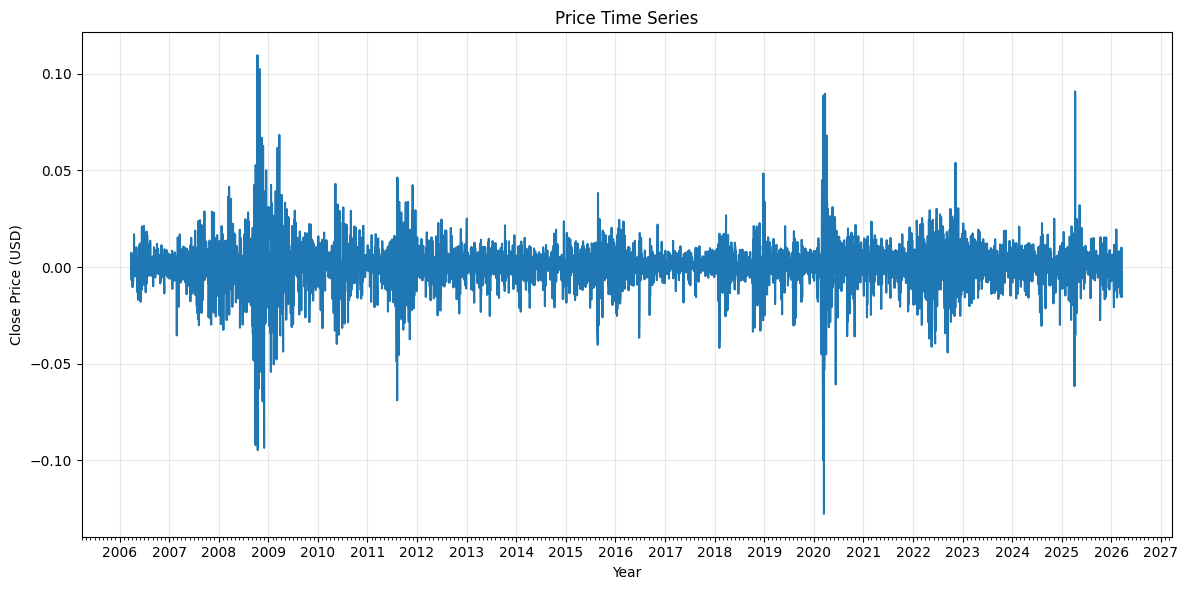

In [ ]:
# Show Sample Graph
Ret_data.index = pd.to_datetime(Ret_data.index, dayfirst= True)
plot_time_series(Ret_data, date_col=Ret_data.index, value_col='sp500', save_path=FIGURE_DIR / "sp500_sample.png")

## Derive Descriptive Statistics

In [ ]:
# 1. 准备资产列表
asset_list = ['Gold', 'Silver', 'Copper', 'Platinum', 'Palladium', 'sp500']
results = []

# 2. 定义计算逻辑函数，避免代码重复
def get_stats(data_subset, asset_name, regime_name):
    series = data_subset[asset_name]
    return {
        'Asset': asset_name,
        'Regime': regime_name,
        'Days': len(series),
        'Return': series.mean() * 252,
        'Volatility': series.std() * np.sqrt(252),
        'Skewness': series.skew(),
        'Kurtosis': series.kurt()
    }

# 3. 循环计算并存入列表
for asset in asset_list:
    # 计算 Normal
    results.append(get_stats(Ret_data[Ret_data['is_panic_day'] == 0], asset, 'Normal(VIX < 30)'))
    
    # 计算 Extreme
    results.append(get_stats(Ret_data[Ret_data['is_panic_day'] == 1], asset, 'Extreme(VIX > 30)'))
    
    # 计算 Overall
    results.append(get_stats(Ret_data, asset, 'Overall'))

# 4. 一次性生成最终表格
stat_df = pd.DataFrame(results)

# 5. 美化：调整列顺序并四舍五入
stat_df = stat_df[['Asset', 'Regime', 'Days', 'Return', 'Volatility', 'Skewness', 'Kurtosis']].round(4)

stat_df = stat_df.set_index(['Asset', 'Regime'])
stat_df


Days  Return  Volatility  Skewness  Kurtosis
Asset     Regime                                                         
Gold      Normal(VIX < 30)   4585  0.0982      0.1693   -0.9530    8.3253
          Extreme(VIX > 30)   447  0.1421      0.2988    0.3104    1.8273
          Overall            5032  0.1022      0.1845   -0.5473    7.2488
Silver    Normal(VIX < 30)   4585  0.1283      0.3293   -1.8067   27.8402
          Extreme(VIX > 30)   447 -0.3190      0.5495   -0.5904    3.4590
          Overall            5032  0.0885      0.3545   -1.5434   21.2226
Copper    Normal(VIX < 30)   4585  0.1333      0.2543   -0.6941   15.8614
          Extreme(VIX > 30)   447 -0.9088      0.4798   -0.0182    1.3026
          Overall            5032  0.0406      0.2823   -0.5881   11.5140
Platinum  Normal(VIX < 30)   4585  0.0840      0.2643   -0.8872   11.1665
          Extreme(VIX > 30)   447 -0.8584      0.4114   -0.5104    3.6132
          Overall            5032  0.0168      0.2777   -0.8823   10.1098
Palladium Normal(VIX < 30)   4585  0.1538      0.3461   -0.3942    5.2169
          Extreme(VIX > 30)   447 -0.9920      0.5966   -0.3689    7.7077
          Overall            5032  0.0503      0.3761   -0.4907    8.5150
sp500     Normal(VIX < 30)   4585  0.1821      0.1417   -0.1916    2.0844
          Extreme(VIX > 30)   447 -0.9351      0.4692    0.0427    1.8861
          Overall            5032  0.0825      0.1956   -0.4743   12.7953

## Visualization
### Scatterplot

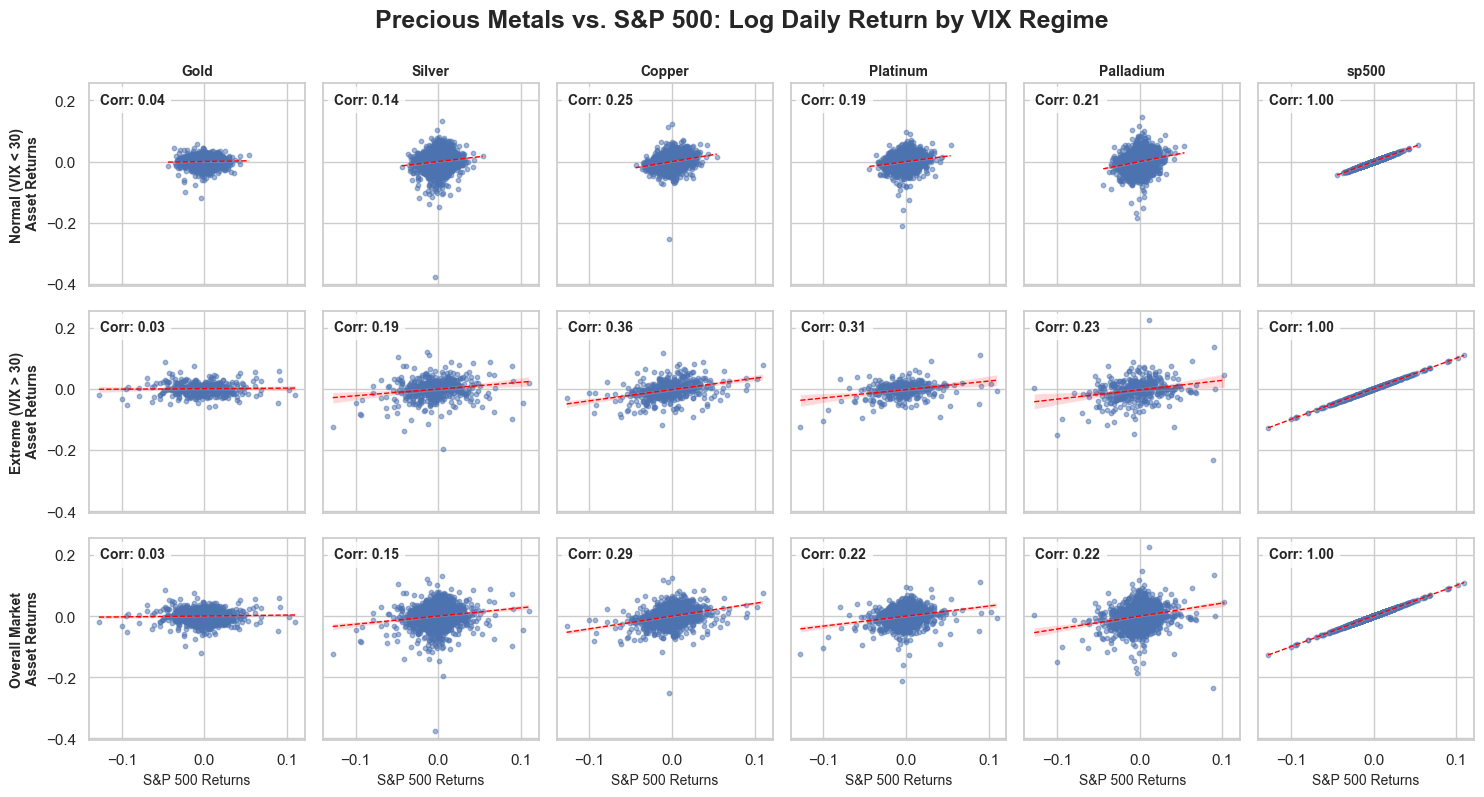

In [ ]:
#asset_list = ['Copper', 'Gold', 'Palladium', 'Platinum', 'Silver', 'sp500']
n = len(asset_list)

# 2. 设置绘图风格
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8), sharex=True, sharey=True)  # 改为3行n列

# 大标题
fig.suptitle('Precious Metals vs. S&P 500: Log Daily Return by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)

regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 3. 开始循环绘图 - 调换循环顺序
for i, regime in enumerate(regimes):  # 外层循环改为regime
    for j, metal in enumerate(asset_list):  # 内层循环改为metal
        ax = axes[i, j]
        
        # 筛选数据
        if regime == 'Overall':
            plot_data = Ret_data
        else:
            plot_data = Ret_data[Ret_data['is_panic_day'] == regime]
            
        # 绘制散点图和回归线
        sns.regplot(
            data=plot_data, 
            x='sp500', 
            y=metal, 
            ax=ax, 
            scatter_kws={'alpha': 0.5, 's': 10}, 
            line_kws={'color': 'red', 'lw': 1, 'linestyle': '--'} 
        )
        
        # 计算相关系数用于标注
        corr = plot_data['sp500'].corr(plot_data[metal])
        ax.text(0.05, 0.9, f'Corr: {corr:.2f}', transform=ax.transAxes, 
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))
        
        # 设置标题和标签
        if i == 0:  # 第一行显示资产名称
            ax.set_title(f'{metal}', fontsize=10, fontweight='bold')
        if j == 0:  # 第一列显示regime标题
            ax.set_ylabel(f'{regime_titles[i]}\n Asset Returns', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == 2:  # 最后一行显示x轴标签
            ax.set_xlabel('S&P 500 Returns', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "precious_metals_sp500_regime_scatter.png", dpi=300, bbox_inches="tight")
#plt.show()

### QQ-Plot

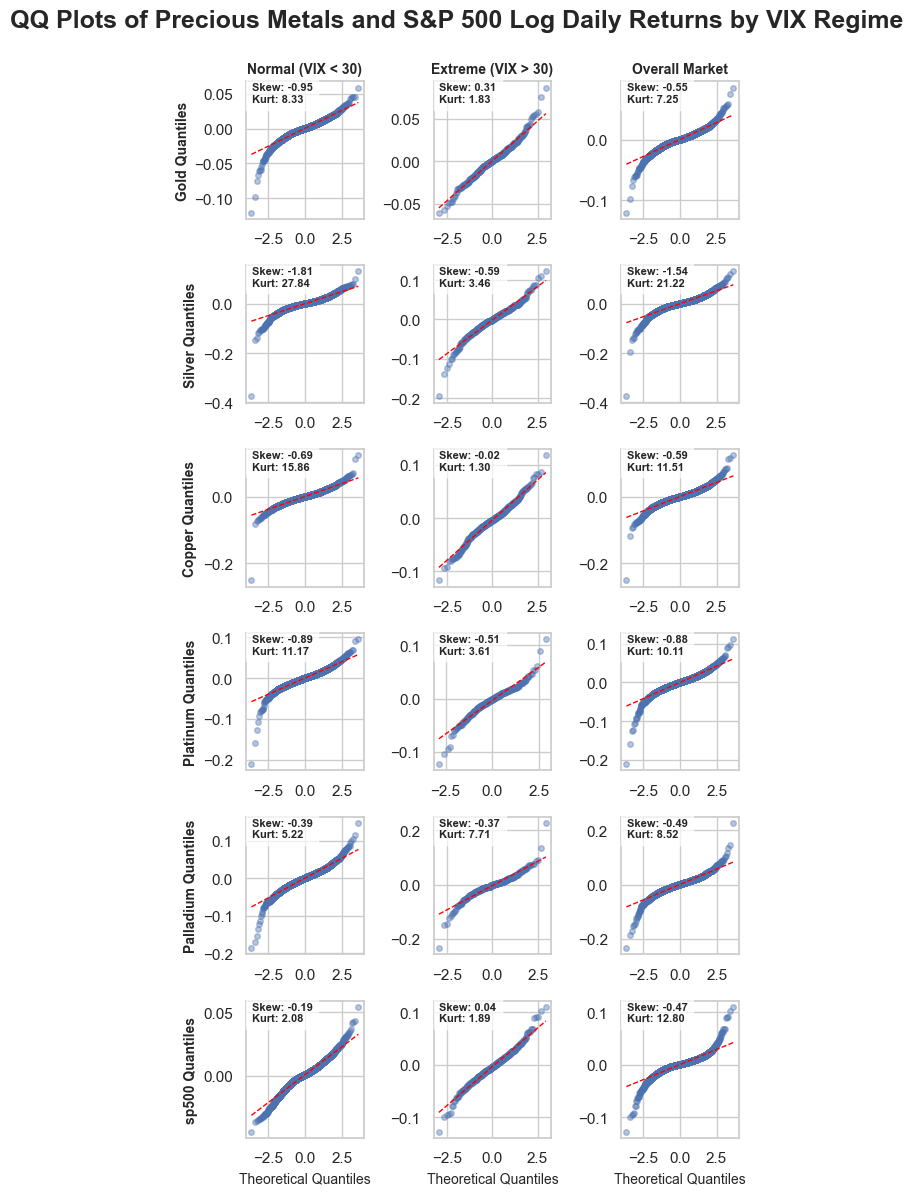

In [ ]:
# 1. 准备资产和机制列表
# asset_list = ['Gold', 'Silver', 'Copper', 'Palladium', 'Platinum']



n = len(asset_list )
regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 2. 创建画布
fig, axes = plt.subplots(n, 3, figsize=(6, 2 * n))
fig.suptitle('QQ Plots of Precious Metals and S&P 500 Log Daily Returns by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)
for i, metal in enumerate(asset_list ):
    for j, regime in enumerate(regimes):
        ax = axes[i, j]
        
        # 筛选子集数据
        if regime == 'Overall':
            data = Ret_data[metal].dropna()
        else:
            data = Ret_data[Ret_data['is_panic_day'] == regime][metal].dropna()
        
        # 绘制 QQ-Plot
        # stats.probplot 会计算理论分位数并返回
        res = stats.probplot(data, dist="norm", plot=ax)
        
        # 自定义视觉效果
        ax.get_lines()[0].set_markerfacecolor('C0') # 散点颜色
        ax.get_lines()[0].set_alpha(0.4)             # 散点透明度
        ax.get_lines()[0].set_markersize(4)          # 散点大小
        ax.get_lines()[1].set_color('red')           # 45度直线颜色
        ax.get_lines()[1].set_linewidth(1)
        ax.get_lines()[1].set_linestyle('--')
        ax.set_title("")
        
        # 标注该子集的偏度和峰度，强化统计结论
        skew = data.skew()
        kurt = data.kurt()
        ax.text(0.05, 0.85, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', 
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7))

        # 设置标题和标签
        if i == 0:
            ax.set_title(regime_titles[j], fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{metal} Quantiles', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == n - 1:
            ax.set_xlabel('Theoretical Quantiles', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "qq_plot_by_metal_regime.png", dpi=300, bbox_inches="tight")
#plt.show()

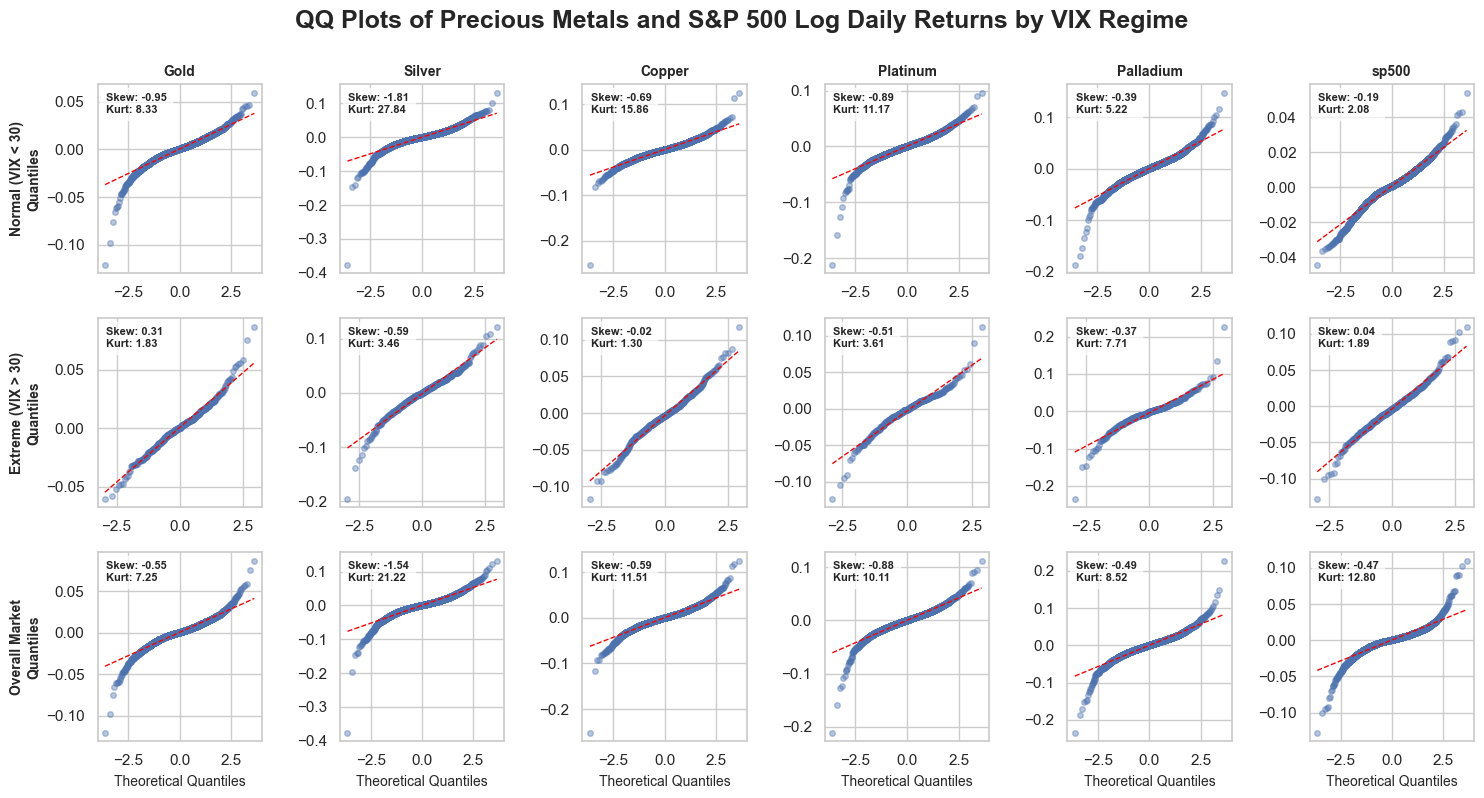

In [ ]:
# 1. 准备资产和机制列表
# asset_list = ['Gold', 'Silver', 'Copper', 'Palladium', 'Platinum']
n = len(asset_list)
regimes = [0, 1, 'Overall']
regime_titles = ['Normal (VIX < 30)', 'Extreme (VIX > 30)', 'Overall Market']

# 2. 创建画布 - 改为横向：3行 n列
fig, axes = plt.subplots(3, n, figsize=(2.5 * n, 8))  # 调换行列，调整 figsize
fig.suptitle('QQ Plots of Precious Metals and S&P 500 Log Daily Returns by VIX Regime', 
             fontsize=18, fontweight='bold', y=0.995)
for i, regime in enumerate(regimes):  # 外层循环改为 regime
    for j, metal in enumerate(asset_list):  # 内层循环改为 metal
        ax = axes[i, j]
        
        # 筛选子集数据
        if regime == 'Overall':
            data = Ret_data[metal].dropna()
        else:
            data = Ret_data[Ret_data['is_panic_day'] == regime][metal].dropna()
        
        # 绘制 QQ-Plot
        res = stats.probplot(data, dist="norm", plot=ax)
        
        # 自定义视觉效果
        ax.get_lines()[0].set_markerfacecolor('C0')
        ax.get_lines()[0].set_alpha(0.4)
        ax.get_lines()[0].set_markersize(4)
        ax.get_lines()[1].set_color('red')
        ax.get_lines()[1].set_linewidth(1)
        ax.get_lines()[1].set_linestyle('--')
        ax.set_title("")
        
        # 标注该子集的偏度和峰度
        skew = data.skew()
        kurt = data.kurt()
        ax.text(0.05, 0.85, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', 
                transform=ax.transAxes, fontsize=8, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.7))

        # 设置标题和标签
        if i == 0:
            ax.set_title(f'{metal}', fontsize=10, fontweight='bold')
        if j == 0:
            ax.set_ylabel(f'{regime_titles[i]}\nQuantiles', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        if i == 2:  # 最后一行
            ax.set_xlabel('Theoretical Quantiles', fontsize=10)
        else:
            ax.set_xlabel('')

plt.tight_layout()
plt.savefig(FIGURE_DIR / "qq_plot_by_regime_metal.png", dpi=300, bbox_inches="tight")
#plt.show()

In [ ]:
events_df = pd.read_csv('data/data_raw/global_market_stress_events.csv')
events_df.head()

,Event Name,Abbreviation,Start Date,End Date
0,Global Financial Crisis,GFC,15/8/2007,8/7/2009
1,Flash Crash & Eurozone Crisis I,EZC-I,6/5/2010,2/7/2010
2,US Credit Rating Downgrade,US-DWN,4/8/2011,8/12/2011
3,China Market Turbulence,CHN-VOL,24/8/2015,1/9/2015
4,Volmageddon & Late-Cycle Correction,VOL-MAX,5/2/2018,26/12/2018


### Rolling Correlation 

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

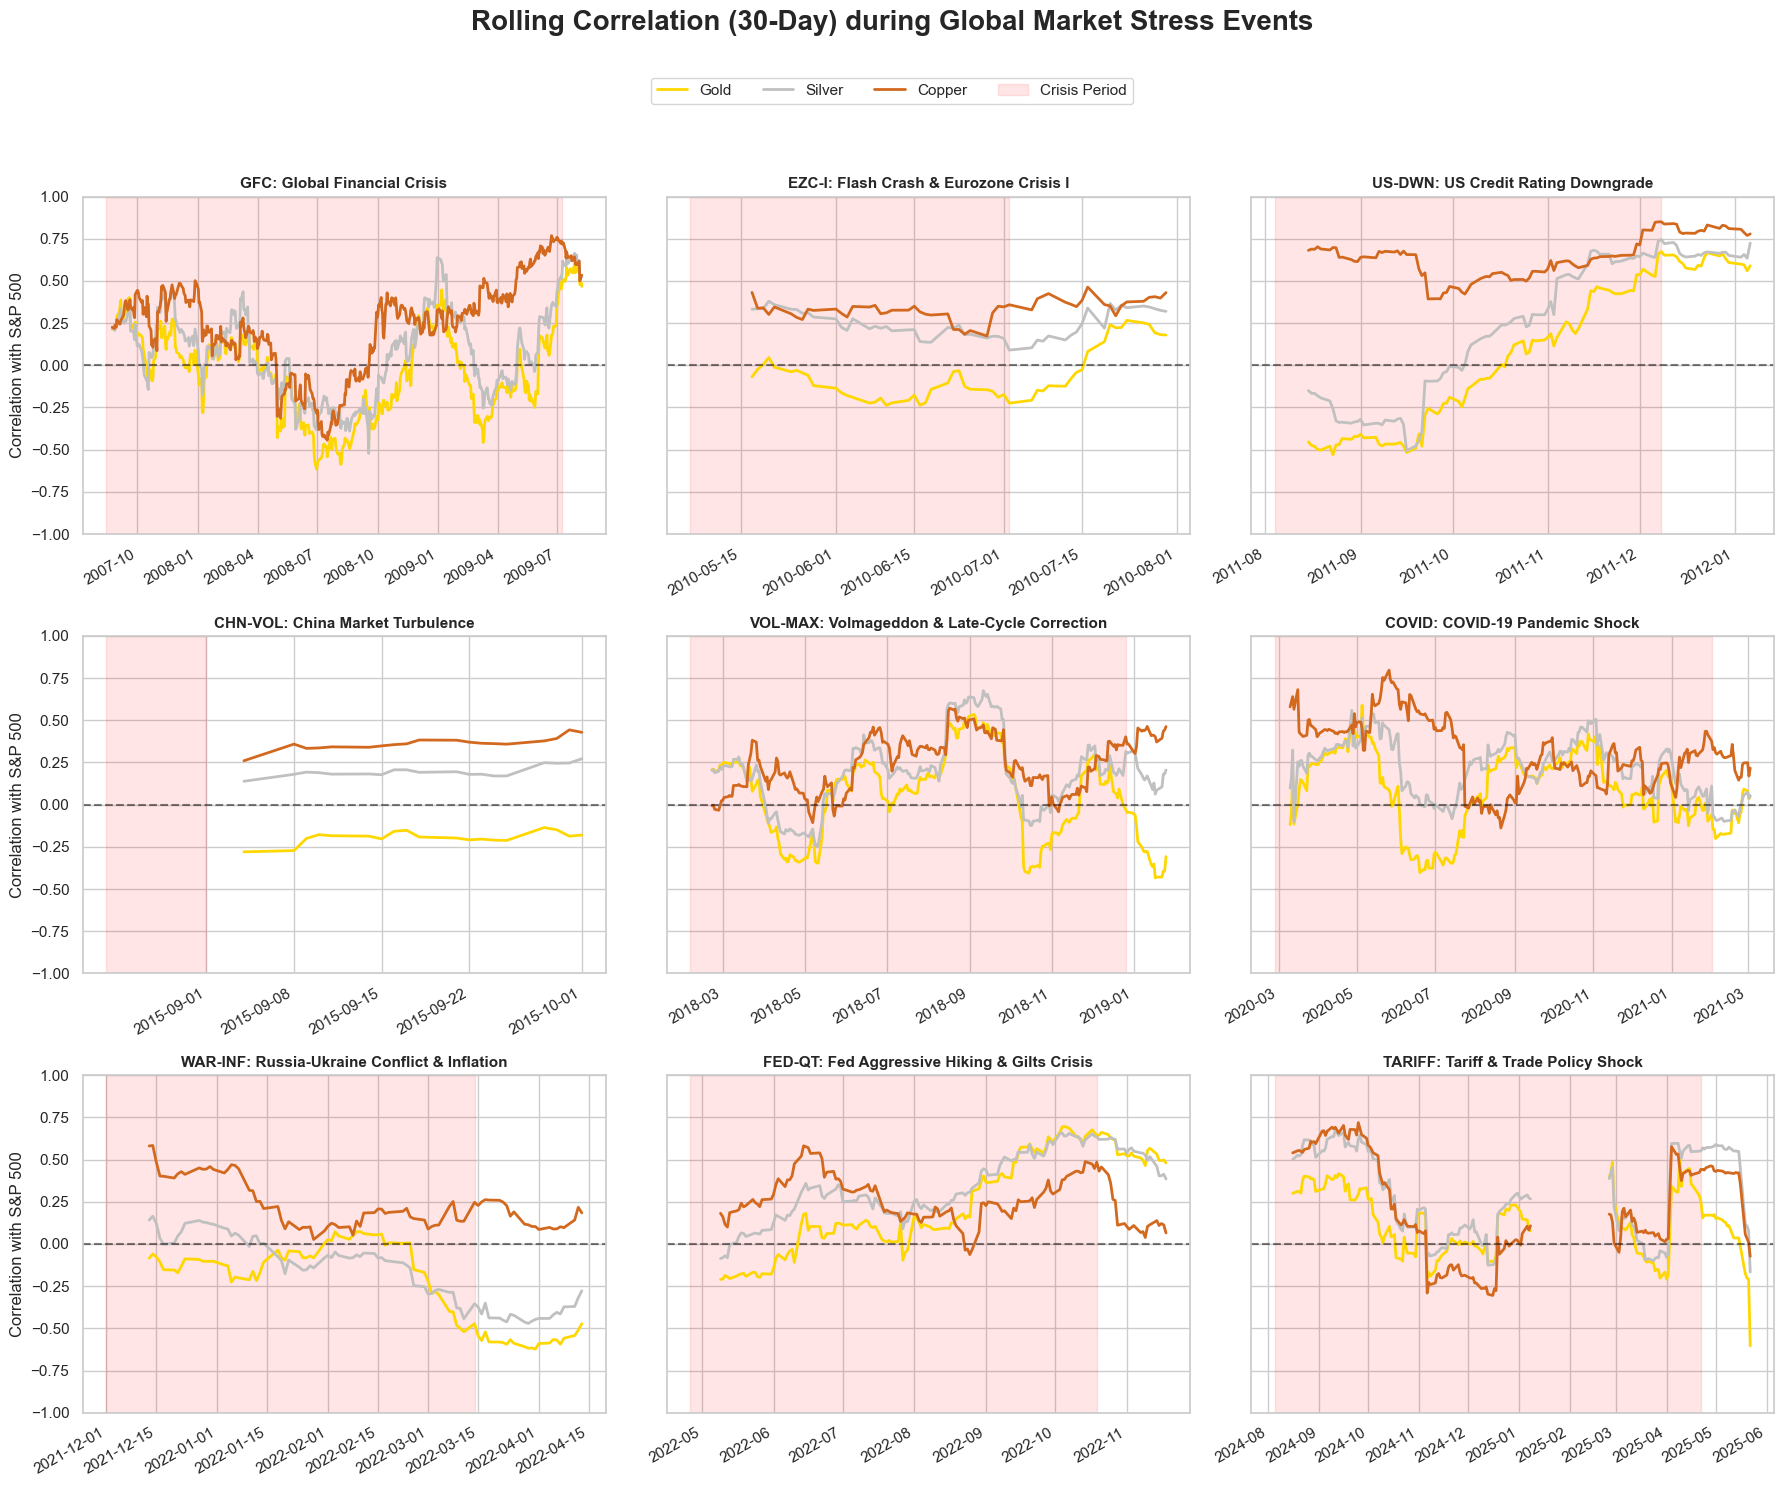

In [ ]:
# 假设 events_df 是你提供的包含 Start Date 和 End Date 的 DataFrame
# 确保日期列是 datetime 格式
events_df['Start Date'] = pd.to_datetime(events_df['Start Date'], dayfirst=True)
events_df['End Date'] = pd.to_datetime(events_df['End Date'], dayfirst=True)

# 设置参数
window = 30  # 危机期间建议窗口调小（如30天），以捕捉快速变化的相关性
metals = ['Gold', 'Silver', 'Copper']
colors = {'Gold': 'gold', 'Silver': 'silver', 'Copper': 'chocolate'}

# 创建 3x3 画布
fig, axes = plt.subplots(3, 3, figsize=(18, 15), sharey=True)
axes = axes.flatten() # 展平以便遍历

for i, (idx, row) in enumerate(events_df.iterrows()):
    if i >= 9: break  # 仅画前9个事件
    
    ax = axes[i]
    event_name = row['Abbreviation']
    start, end = row['Start Date'], row['End Date']
    
    # 稍微拓宽时间范围以便观察危机前后的对比 (比如提前30天，延后30天)
    plot_start = start - pd.Timedelta(days=30)
    plot_end = end + pd.Timedelta(days=30)
    
    # 切片数据
    mask = (Ret_data.index >= plot_start) & (Ret_data.index <= plot_end)
    subset = Ret_data.loc[mask]
    
    for metal in metals:
        # 计算滚动相关性
        roll_corr = subset[metal].rolling(window=window).corr(subset['sp500'])
        ax.plot(roll_corr, label=f'{metal}', color=colors[metal], lw=2)
    
    # 标记实际危机发生的区间
    ax.axvspan(start, end, color='red', alpha=0.1, label='Crisis Period')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # 格式化子图
    ax.set_title(f"{event_name}: {row['Event Name']}", fontsize=11, fontweight='bold')
    ax.set_ylim(-1, 1)
    if i % 3 == 0: ax.set_ylabel("Correlation with S&P 500")
    
    # 设置日期显示格式（避免重叠）
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 处理多余的子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 全局美化
plt.suptitle(f"Rolling Correlation ({window}-Day) during Global Market Stress Events", fontsize=20,fontweight = 'bold', y=1.02)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(FIGURE_DIR / "rolling_corr_stress_events.png", dpi=300, bbox_inches="tight")
# plt.show()

### Maximum Drawback Comparison

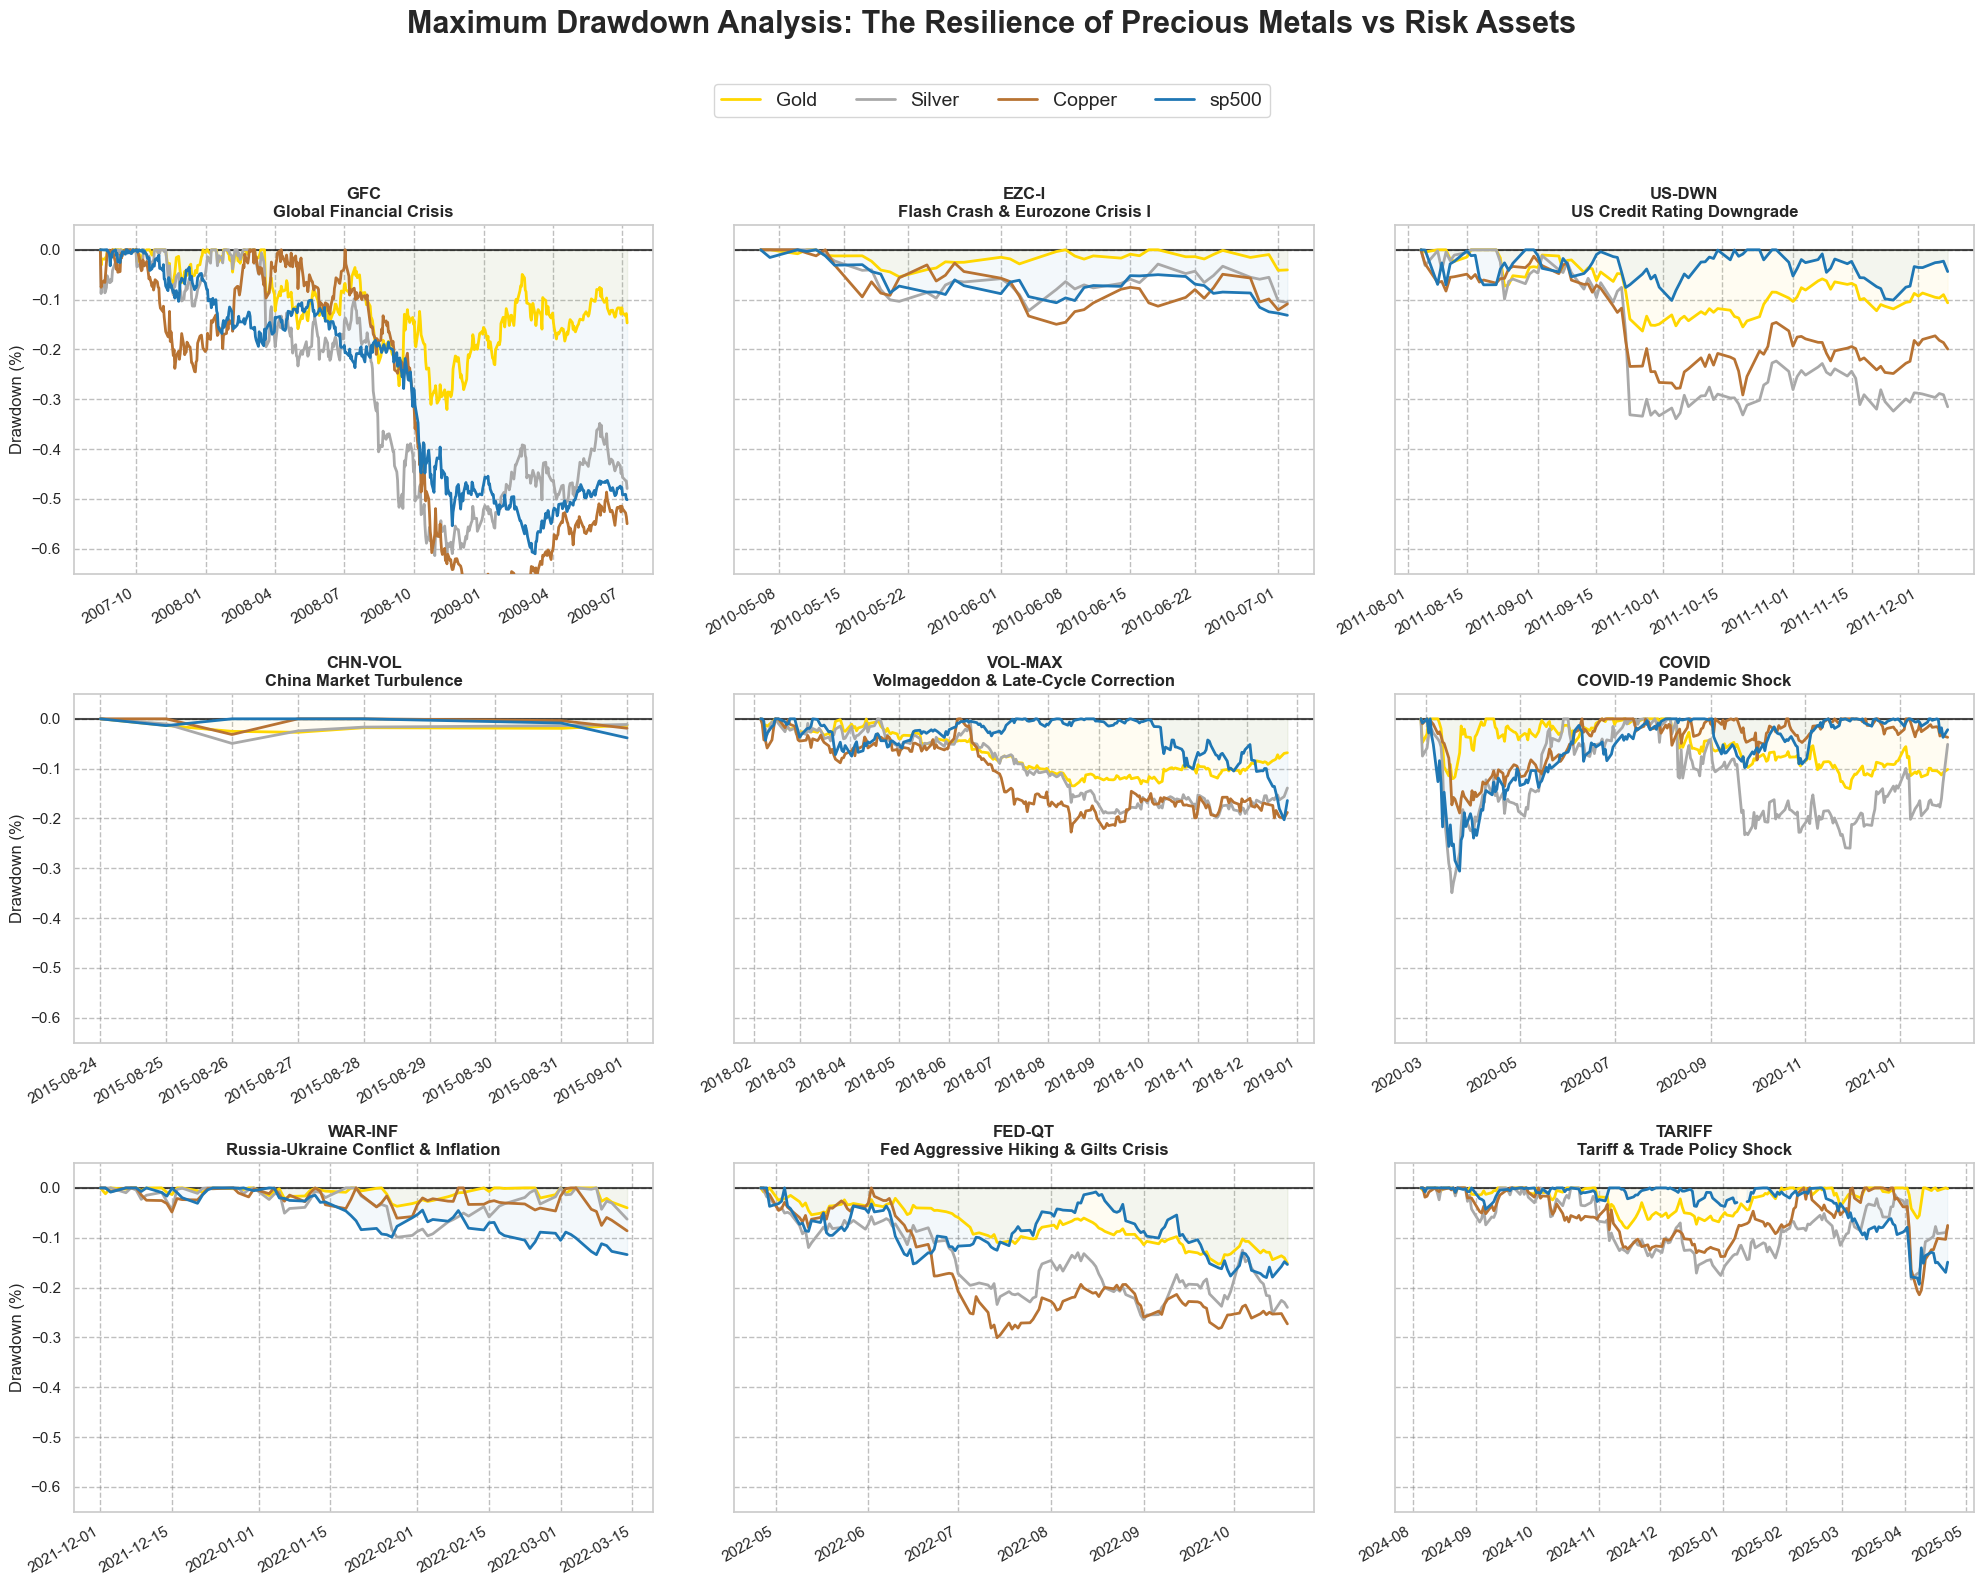

In [ ]:
# 确保日期格式正确
events_df['Start Date'] = pd.to_datetime(events_df['Start Date'], dayfirst=True)
events_df['End Date'] = pd.to_datetime(events_df['End Date'], dayfirst=True)

# 资产配置：增加白银 (Silver) 并设置专业配色
assets_to_compare = ['Gold', 'Silver', 'Copper', 'sp500'] 
colors = {
    'Gold': '#FFD700',    # 金色
    'Silver': '#A9A9A9',  # 深灰色（代表白银）
    'Copper': '#B87333',  # 铜色
    'sp500': '#1f77b4'    # 蓝色（标普500）
}

fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharey=True)
axes = axes.flatten()

for i, (idx, row) in enumerate(events_df.iterrows()):
    if i >= 9: break
    
    ax = axes[i]
    start, end = row['Start Date'], row['End Date']
    
    # 提取危机期间的数据
    mask = (Ret_data.index >= start) & (Ret_data.index <= end)
    subset = Ret_data.loc[mask].copy()
    
    if subset.empty: continue

    for asset in assets_to_compare:
        # 1. 计算累积收益率
        cum_ret = (1 + subset[asset]).cumprod()
        
        # 2. 计算滚动最高点
        running_max = cum_ret.cummax()
        
        # 3. 计算回撤 (Drawdown)
        drawdown = (cum_ret / running_max) - 1
        
        # 4. 绘制曲线
        ax.plot(drawdown, label=asset, color=colors[asset], lw=2, zorder=3)
        # 为最核心的黄金和标普500添加轻微填充，增强对比感
        if asset in ['Gold', 'sp500']:
            ax.fill_between(drawdown.index, drawdown, 0, color=colors[asset], alpha=0.05)

    # --- 修改建议 1：添加灰色网格线 ---
    ax.grid(True, which='major', linestyle='--', color='gray', alpha=0.5, zorder=1)
    
    # 格式化子图
    ax.set_title(f"{row['Abbreviation']}\n{row['Event Name']}", fontsize=12, fontweight='bold')
    ax.set_ylim(-0.65, 0.05) # 稍微扩大纵轴范围以容纳白银可能的波动
    ax.axhline(0, color='black', lw=1.5, alpha=0.7, zorder=2)
    
    if i % 3 == 0:
        ax.set_ylabel("Drawdown (%)", fontsize=12)
    
    # 日期刻度美化
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# 清理多余子图
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Maximum Drawdown Analysis: The Resilience of Precious Metals vs Risk Assets", fontsize=22, fontweight = 'bold', y=1.02)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(FIGURE_DIR / "drawdown_stress_events.png", dpi=300, bbox_inches="tight")
plt.show()

# HMM

## Prepare HMM Dataset
- DFII10（10Y TIPS 实际利率）
- T10YIE（10Y 盈亏平衡通胀预期）

日期区间与 `LogRet_data.csv` 一致。）。

In [31]:
_logret_dates = pd.read_csv("data/data_processed/LogRet_data.csv", parse_dates=["Date"])
obs_start = _logret_dates["Date"].min().strftime("%Y-%m-%d")
obs_end = _logret_dates["Date"].max().strftime("%Y-%m-%d")

dfii10 = utility_func.fetch_fred_series("DFII10", obs_start, obs_end)
t10yie = utility_func.fetch_fred_series("T10YIE", obs_start, obs_end)
comm_dat = yf.download(["GC=F", "CL=F", 'HG=F'], start=obs_start, end=obs_end)['Close']
comm_dat['gold_oil_ratio'] = comm_dat['GC=F'] / comm_dat['CL=F']
comm_dat['gold_copper_ratio'] = comm_dat['GC=F'] / comm_dat['HG=F']
comm_dat = comm_dat.reset_index().rename(columns={"Date": "date"})

features_df = dfii10.merge(t10yie, on="date", how="outer").sort_values("date")
features_df = features_df.merge(comm_dat[['date', 'gold_oil_ratio', 'gold_copper_ratio']], on="date", how="outer").sort_values("date")

# 全历史日频序列（周末/节假日无观测）
features_df.to_csv("HMM_features.csv", index=False)

# 与 LogRet 交易日对齐（按日历日 merge；非交易日沿用最近观测可用 ffill）
features_df = (
    _logret_dates[["Date"]]
    .merge(features_df.rename(columns={"date": "Date"}), on="Date", how="left")
    .sort_values("Date")
)

gold_log_ret = pd.read_csv(DATA_PROCESSED_DIR + 'LogRet_data.csv')
gold_log_ret = gold_log_ret[['Date', 'Gold', 'sp500']]
gold_log_ret['Date'] = pd.to_datetime(gold_log_ret['Date'])
features_df = features_df.merge(gold_log_ret, on="Date", how="outer").sort_values("Date")
features_df.rename(columns={'Gold': 'gold_log_ret', 'sp500': 'sp500_log_ret'}, inplace=True)

features_df.to_csv("HMM_features.csv", index=False)

print(f"Time Interval: {obs_start} ~ {obs_end}")
print(features_df.head())
print("...")
print(features_df.tail())

[*********************100%***********************]  3 of 3 completed

Time Interval: 2006-02-16 ~ 2026-02-10
        Date  DFII10  T10YIE  gold_oil_ratio  gold_copper_ratio  gold_log_ret  \
0 2006-02-16    2.10    2.49        9.339720         244.076890      0.011606   
1 2006-02-17    2.03    2.51        9.215096         249.796270      0.010567   
2 2006-02-21    2.04    2.53        9.065467         242.832113      0.003799   
3 2006-02-22    2.01    2.52        9.078840         244.439548      0.000000   
4 2006-02-23    2.03    2.53        9.058474         248.144803     -0.009979   

   sp500_log_ret  
0       0.007301  
1      -0.001661  
2      -0.003276  
3       0.007485  
4      -0.003782  
...
           Date  DFII10  T10YIE  gold_oil_ratio  gold_copper_ratio  \
5027 2026-02-04    1.94    2.35       75.535768         844.558826   
5028 2026-02-05    1.89    2.32       76.811500         838.316965   
5029 2026-02-06    1.88    2.34       77.910311         844.410351   
5030 2026-02-09    1.87    2.35       78.478867         849.604669   
5031 2

## Feature Engineering

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

df = pd.read_csv('HMM_features.csv')
# 1. 计算利率的一阶差分 (First Difference)
df['diff_DFII10'] = df['DFII10'].diff()
df['diff_T10YIE'] = df['T10YIE'].diff()

# 2. 计算比率的变化率 (或者也可以用 diff)
df['d_gold_oil'] = df['gold_oil_ratio'].pct_change()
df['d_gold_copper'] = df['gold_copper_ratio'].pct_change()

# 3. 筛选建模特征并删除空值
features = ['gold_log_ret', 'sp500_log_ret', 'diff_DFII10', 'd_gold_copper']
df_model = df.dropna(subset=features)

# 4. 标准化特征矩阵 X
scaler = StandardScaler()
X = scaler.fit_transform(df_model[features])

C:\Users\jimmy\AppData\Local\Temp\ipykernel_82420\3830150677.py:12: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['d_gold_oil'] = df['gold_oil_ratio'].pct_change()
C:\Users\jimmy\AppData\Local\Temp\ipykernel_82420\3830150677.py:13: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['d_gold_copper'] = df['gold_copper_ratio'].pct_change()


## Fit the Model

In [34]:
# 初始化模型：2个状态 (正常 vs 危机)
# hmmlearn 的 GaussianHMM 无 n_init；需要多次随机起点时可循环 random_state 并比较 model.score(X)
model = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000, random_state=42)

# 拟合模型
model.fit(X)

# 预测隐藏状态 (0 或 1)
hidden_states = model.predict(X)
df_model['state'] = hidden_states

# 查看每个状态下的特征均值
state_means = pd.DataFrame(scaler.inverse_transform(model.means_), columns=features)
print("各状态特征均值:\n", state_means)

# 查看每个状态下的协方差矩阵 (关键：看金和标普的相关性)
for i in range(model.n_components):
    print(f"状态 {i} 的协方差矩阵:\n", model.covars_[i])

各状态特征均值:
    gold_log_ret  sp500_log_ret  diff_DFII10  d_gold_copper
0      0.000755       0.001036    -0.000132       0.000011
1     -0.000718      -0.002277    -0.000082       0.001846
状态 0 的协方差矩阵:
 [[ 0.55144895  0.01942629 -0.15126933  0.17821839]
 [ 0.01942629  0.35903041  0.05406373 -0.11032383]
 [-0.15126933  0.05406373  0.56252262 -0.10731408]
 [ 0.17821839 -0.11032383 -0.10731408  0.5493061 ]]
状态 1 的协方差矩阵:
 [[ 2.69041399  0.03357805 -0.41934756  0.81334229]
 [ 0.03357805  3.37590736  0.32221961 -0.83861769]
 [-0.41934756  0.32221961  2.66123852 -0.30365346]
 [ 0.81334229 -0.83861769 -0.30365346  2.70285667]]


C:\Users\jimmy\AppData\Local\Temp\ipykernel_82420\1988967197.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['state'] = hidden_states


C:\Users\jimmy\AppData\Local\Temp\ipykernel_82420\1383586796.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['Date'] = pd.to_datetime(df_model['Date'])


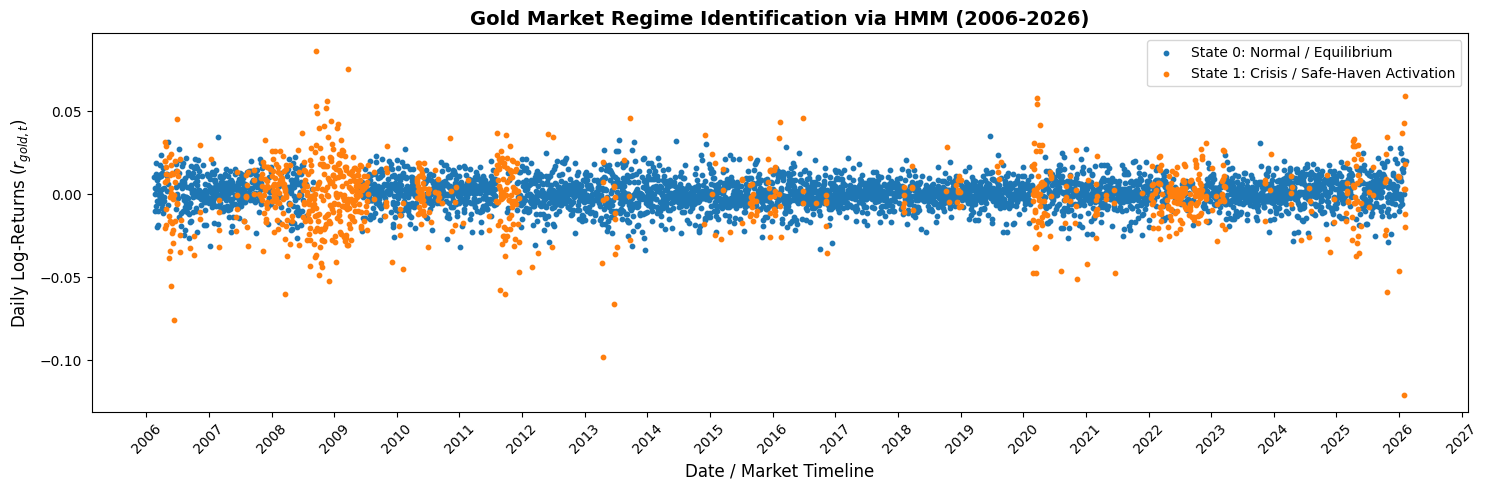

In [39]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 确保 'Date' 列为 datetime 类型
df_model['Date'] = pd.to_datetime(df_model['Date'])

plt.figure(figsize=(15, 5))
for i in range(model.n_components):
    state_data = df_model[df_model['state'] == i]
    # 设置时间戳为 x 轴，直接用 pd.Timestamp 数据
    plt.scatter(state_data['Date'], state_data['gold_log_ret'], label=f'State {i}', s=10)

plt.title("Gold Market Regime Identification via HMM (2006-2026)", fontsize=14, fontweight='bold')
plt.ylabel("Daily Log-Returns ($r_{gold,t}$)", fontsize=12)
plt.xlabel("Date / Market Timeline", fontsize=12)
plt.legend(["State 0: Normal / Equilibrium", "State 1: Crisis / Safe-Haven Activation"], loc='upper right')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [36]:
# 假设 model 已经 fit 好了，X 是标准化后的特征矩阵
means = model.means_  # 形状为 (n_components, n_features)
covars = model.covars_ # 形状为 (n_components, n_features, n_features)

import numpy as np

# 计算判别得分 (Simplified version)
scores = {}
for i, feature in enumerate(features):
    m0, m1 = means[0, i], means[1, i]
    s0, s1 = np.sqrt(covars[0, i, i]), np.sqrt(covars[1, i, i])
    scores[feature] = abs(m1 - m0) / (s0 + s1)

# 排序输出
sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
for f, s in sorted_scores:
    print(f"特征 {f} 的解释力度 (Discriminative Score): {s:.4f}")

特征 sp500_log_ret 的解释力度 (Discriminative Score): 0.1111
特征 gold_log_ret 的解释力度 (Discriminative Score): 0.0535
特征 d_gold_copper 的解释力度 (Discriminative Score): 0.0436
特征 diff_DFII10 的解释力度 (Discriminative Score): 0.0004


## Model Testing
### Walk-forward Testing

In [40]:
import numpy as np
import pandas as pd
from hmmlearn.hmm import GaussianHMM

# 假设 X 是你之前准备好的标准化特征矩阵 (Standardized Features)
# n_train 是初始训练集长度，step 是每次滑动的步长（如 20 个交易日，即一个月）
n_total = len(X)
n_train = 252 * 5  # 初始用 5 年数据
step = 22          # 每月更新一次模型
oos_states = []    # 存储样本外预测的状态
oos_dates = []     # 存储对应的日期

# Walk-forward 循环
for i in range(n_train, n_total, step):
    # 1. 定义当前的训练集 (Expanding Window 模式)
    X_train = X[:i]
    
    # 2. 定义测试集 (接下来一个月的数据)
    test_end = min(i + step, n_total)
    X_test = X[i:test_end]
    
    # 3. 重新训练 HMM 模型
    # 注意：为了保持状态定义的一致性，可以考虑用上一个窗口的均值作为初始值
    model = GaussianHMM(n_components=2, covariance_type='full', n_iter=1000)
    model.fit(X_train)
    
    # 4. 样本外预测 (Predicting the latent states for the unseen month)
    # 使用 model.predict 或 model.predict_proba
    current_oos_states = model.predict(X_test)
    
    oos_states.extend(current_oos_states)
    oos_dates.extend(df_model.iloc[i:test_end]['Date'])

# 将结果存入新的 DataFrame
df_oos = pd.DataFrame({'Date': oos_dates, 'OOS_State': oos_states})

In [41]:
# 将收益率合并回 df_oos 进行统计
df_oos = df_oos.merge(df_model[['Date', 'gold_log_ret', 'sp500_log_ret']], on='Date')

# 按状态分组查看统计指标
oos_stats = df_oos.groupby('OOS_State').agg({
    'sp500_log_ret': ['mean', 'std'],
    'gold_log_ret': ['mean', 'std']
})
print(oos_stats)

# 计算 OOS 期间不同状态的相关性
for state in [0, 1]:
    corr = df_oos[df_oos['OOS_State'] == state][['gold_log_ret', 'sp500_log_ret']].corr().iloc[0, 1]
    print(f"OOS 状态 {state} 的相关性: {corr:.4f}")

          sp500_log_ret           gold_log_ret          
                   mean       std         mean       std
OOS_State                                               
0              0.000219  0.010977     0.000351  0.010529
1              0.000745  0.010943     0.000296  0.010721
OOS 状态 0 的相关性: 0.0528
OOS 状态 1 的相关性: 0.0106


### Economic Value Test

Text(0.5, 1.0, 'OOS Strategy Performance vs S&P 500 Buy-and-Hold')

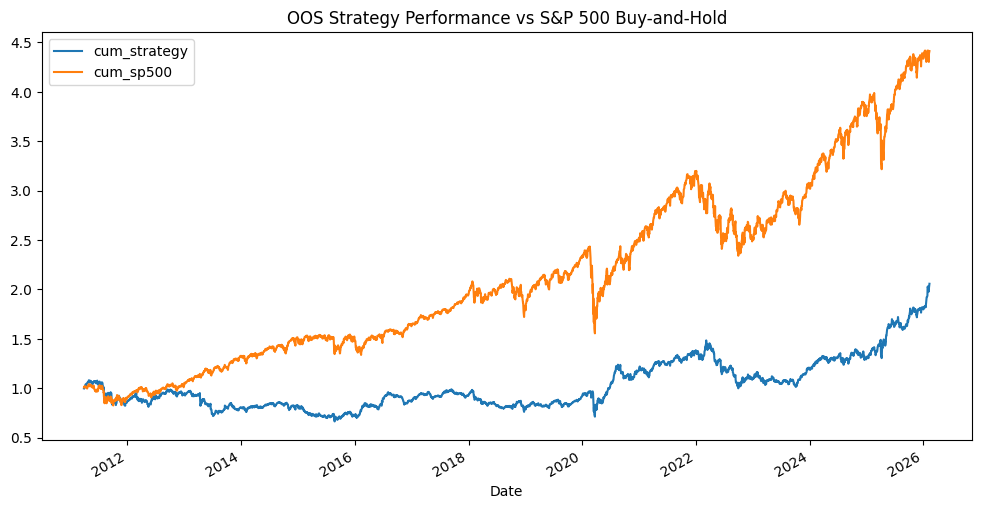

In [42]:
# 简单回测示例
df_oos['strategy_ret'] = np.where(df_oos['OOS_State'] == 0, 
                                  df_oos['sp500_log_ret'], 
                                  df_oos['gold_log_ret'])

# 计算累计收益
df_oos['cum_strategy'] = (1 + df_oos['strategy_ret']).cumprod()
df_oos['cum_sp500'] = (1 + df_oos['sp500_log_ret']).cumprod()

# 可视化对比
df_oos.set_index('Date')[['cum_strategy', 'cum_sp500']].plot(figsize=(12,6))
plt.title("OOS Strategy Performance vs S&P 500 Buy-and-Hold")